# Introduction to Machine Learning

## Practice class 01 - kNN (k Nearest Neighbour)

**Preparation**
You can use the virtual environment from the previous semester. For todays class, and most of the classes during the semester you are going to need the `scikit-learn` package ([documentation](https://scikit-learn.org/stable/)). To install it type to the terminal:
```bash
pip install scikit-learn
```

**Introduction**
* **k-NN** is a simple, non-parametric, and instance-based supervised learning algorithm used for classification and regression
* It works by finding the `k` closest data points (neighbors) in the feature space and making predictions based on their labels (for classification) or values (for regression).
* Distance metrics (e.g., Euclidean, Manhattan) are used to measure the similarity between data points.
* The choice of `k` (number of neighbors) is crucial: a small `k` can lead to overfitting, while a large `k` can lead to underfitting.

**Key Concepts**
* **Feature Space:** The n-dimensional space where each data point is represented.
* **Distance Metric:** A measure of similarity between data points (e.g., Euclidean distance).
* **Majority Voting:** For classification, the class with the most votes among the `k` neighbors is selected.
* **Weighted Voting:** Neighbors can be weighted by their distance (closer neighbors have more influence).

**Where is it effective to use kNN?**
* **Low to medium dimensional data**, e.g. up to 10 features.
* **Clear separation between classes.** The dataset has to be well separated in the feature space.
* **Small to medium size.** It is computationall expensive to calculate the distance for all the neighbours. 

### Task 1 - Synthetic datasets for classification

First we create our own dataset and demonstrate how kNN works.
1. Consider 3 points in a two dimensional space $(0,0)$, $(1,0)$, $(0,1)$. Around each point generate a cloud of 30 random points with normal distribution and $\sigma=0.25$. Use 42 for the random seed. This way we have a 2 dimensional feature space with 3 species. This is going to be your train dataset.
2. Plot your data. Use a scatter plot with different colours for the different species.
3. Implement `knn_predict(x_train,y_train,x_test,k)`, where `x_train` is the training data, your previously generated 2 dimensional data points, `y_train` is the labels of your training data points, `x_test` is an array of 2 dimensional test points and `k` is the number of nearest neighbours you want to consider. The function predicts the species by taking the `k` neareast neighbours and then applying majority voting for the prediction.
3. Take 100 test points uniformly in a sphere with radius 1 and centered around $(1/2,1/2)$. Be careful, it is not straightforward to generate uniform points inside a sphere! Test the accuracy of your prediction algorithm for $k\in(1,10)$. The correct label of a point is the label of the closest corner of your original triangle. Plot your accuracy as a function of `k`. Or in other words perform hyperparameter tuning, to find the optimal hyperparameter.
4. Plot the decision bounderies on the $x\in(-1,2)$ and $y\in(-1,2)$ interval. Create a meshgrid, and apply the prediction function for each of your points. 

In [9]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import rcParams
# Can be used for majority voting
from collections import Counter

rcParams['font.size']=16

# Dataset generation
initial_points = np.array([[0,0], [1, 0], [0, 1]])

train_dataset = np.array([]).reshape(0, 2)
number_generated = 30
deviation = 0.25

np.random.seed(42)
for i, center in enumerate(initial_points):
    points = np.random.normal(loc=center, scale=deviation, size=(number_generated, 2))
    train_dataset = np.vstack((train_dataset, points))
    print(f"Class {i}: {points.shape[0]} points generated around center {center}")

Class 0: 30 points generated around center [0 0]
Class 1: 30 points generated around center [1 0]
Class 2: 30 points generated around center [0 1]


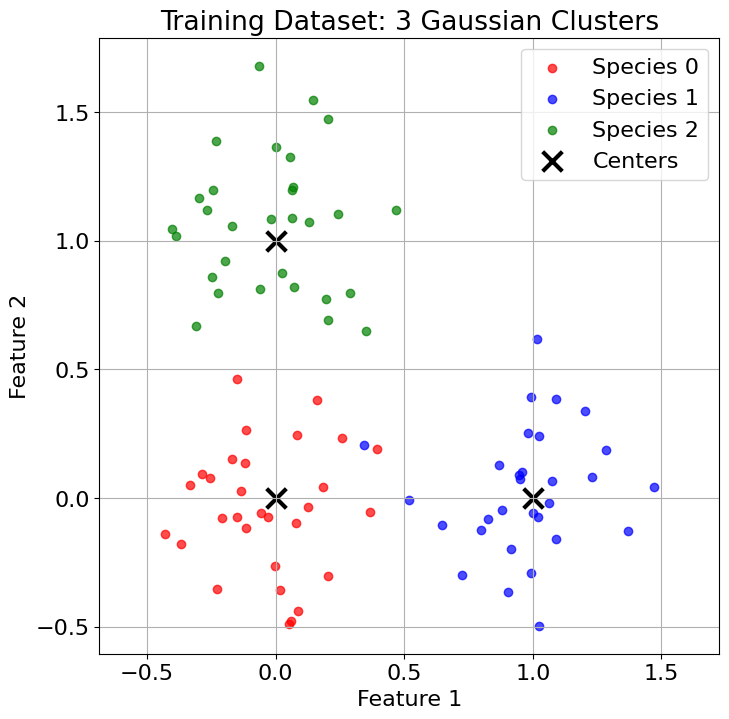

In [10]:
# Plotting
colors = ['red', 'blue', 'green']

plt.figure(figsize=(8, 8))

for i in range(3):
    plt.scatter(
        train_dataset[i*number_generated:(i+1)*number_generated, 0],
        train_dataset[i*number_generated:(i+1)*number_generated, 1],
        color=colors[i],
        label=f"Species {i}",
        alpha=0.7
    )

# Plot centers
plt.scatter(
    initial_points[:, 0],
    initial_points[:, 1],
    color='black',
    marker='x',
    s=200,
    linewidths=3,
    label="Centers"
)

plt.title("Training Dataset: 3 Gaussian Clusters")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()

In [11]:
# KNN Implementation

x_train = train_dataset
y_train = np.array([0]*number_generated + [1]*number_generated + [2]*number_generated)
k = 3

def distance(point1, point2):
    return np.linalg.norm(point1 - point2)

def knn_predict(x_train, y_train, x_test, k):
    predictions = []
    for x in x_test:
        distances = np.linalg.norm(x_train - x, axis=1)  # vectorised distance
        closest_indices = np.argsort(distances)[:k]
        closest_labels = y_train[closest_indices]
        predictions.append(Counter(closest_labels).most_common(1)[0][0])
    return np.array(predictions)

print("Predictions for test points:")
test_points = np.array([[0.5, 0.5], [1.5, 0.5], [0.5, 1.5]])
predicted_labels = knn_predict(x_train, y_train, test_points, k)
for point, label in zip(test_points, predicted_labels):
    print(f"Test point {point} is predicted to belong to species {label}")

Predictions for test points:
Test point [0.5 0.5] is predicted to belong to species 2
Test point [1.5 0.5] is predicted to belong to species 1
Test point [0.5 1.5] is predicted to belong to species 2


k= 1  accuracy=0.93
k= 2  accuracy=0.93
k= 3  accuracy=0.96
k= 4  accuracy=0.95
k= 5  accuracy=0.97
k= 6  accuracy=0.96
k= 7  accuracy=0.97
k= 8  accuracy=0.97
k= 9  accuracy=0.97
k=10  accuracy=0.98


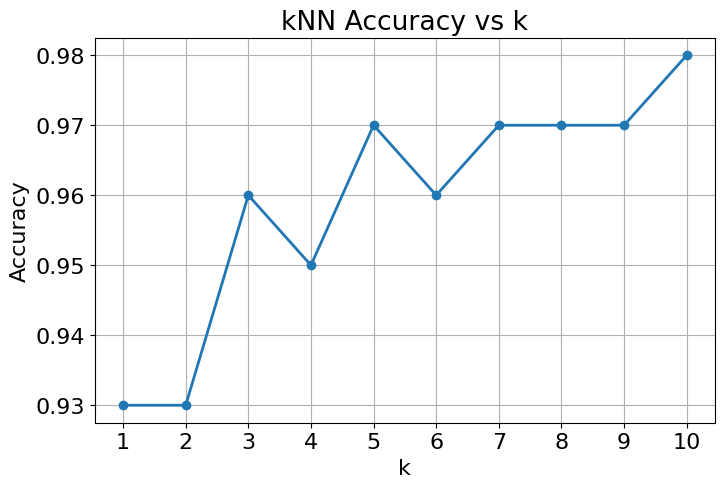


Best k: 10 with accuracy 0.98


In [12]:
# Circle
center = np.array([0.5, 0.5])
radius = 1
number_test_points = 100
test_k = np.arange(1, 11)

def generate_points_on_circle(center, radius, num_points):
    u = np.random.rand(num_points)
    theta = np.random.rand(num_points) * 2 * np.pi
    r = radius * np.sqrt(u)
    x = center[0] + r * np.cos(theta)
    y = center[1] + r * np.sin(theta)
    generated_points = np.column_stack((x, y))
    return generated_points

# Generate points
test_points_circle = generate_points_on_circle(num_points=number_test_points, center=center, radius=radius)

# True labels: label of the closest corner/initial_point
dist_to_corners = np.linalg.norm(test_points_circle[:, None, :] - initial_points[None, :, :], axis=2)
true_labels = np.argmin(dist_to_corners, axis=1)


# Accuracy vs k
test_k = np.arange(1, 11)
accuracies = []

for k in test_k:
    preds = knn_predict(x_train, y_train, test_points_circle, k)
    acc = np.mean(preds == true_labels)
    accuracies.append(acc)
    print(f"k={k:2d}  accuracy={acc:.2f}")

plt.figure(figsize=(8, 5))
plt.plot(test_k, accuracies, marker='o', linewidth=2)
plt.xticks(test_k)
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("kNN Accuracy vs k")
plt.grid(True)
plt.show()

print(f"\nBest k: {test_k[np.argmax(accuracies)]} with accuracy {max(accuracies):.2f}")


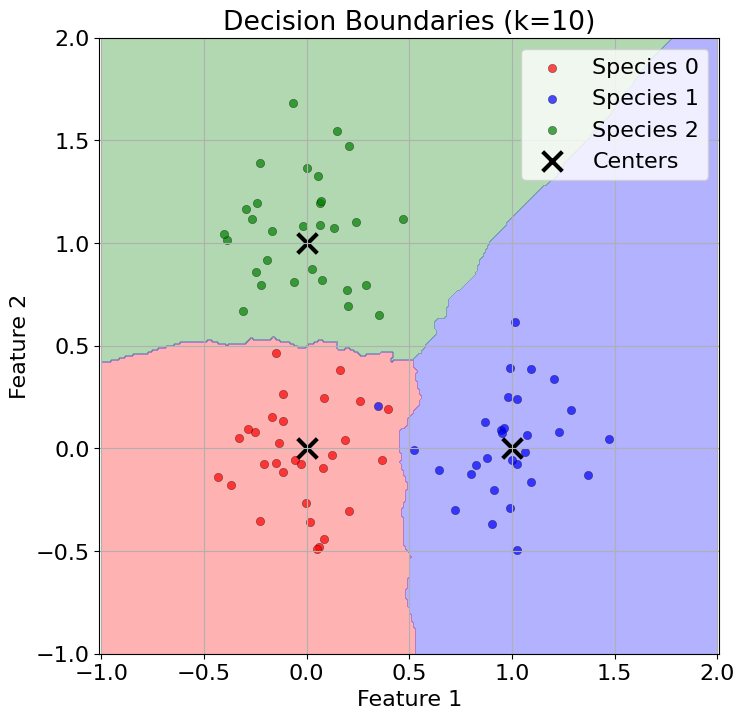

In [13]:
# Decision boundaries
x_range = np.linspace(-1, 2, 300)
y_range = np.linspace(-1, 2, 300)
xx, yy = np.meshgrid(x_range, y_range)
grid_points = np.column_stack([xx.ravel(), yy.ravel()])

best_k = test_k[np.argmax(accuracies)]
grid_preds = knn_predict(x_train, y_train, grid_points, k=best_k).reshape(xx.shape)

plt.figure(figsize=(8, 8))
plt.contourf(xx, yy, grid_preds, alpha=0.3, colors=colors, levels=[-0.5, 0.5, 1.5, 2.5])
for i in range(3):
    plt.scatter(
        train_dataset[i*number_generated:(i+1)*number_generated, 0],
        train_dataset[i*number_generated:(i+1)*number_generated, 1],
        color=colors[i], label=f"Species {i}", alpha=0.7, edgecolors='k', linewidths=0.3
    )
plt.scatter(initial_points[:, 0], initial_points[:, 1],
            color='black', marker='x', s=200, linewidths=3, label="Centers")
plt.title(f"Decision Boundaries (k={best_k})")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()

### Task 2 - Use the built in functions
We are going to solve the same problem, but with the `sklearn` built in functions and see how simple it is.
1. Copy your code what generates the train dataset.
2. Initialize a `kNeighborsClassifier` with `n_neighbours=3`.
3. Use the `.fit()` method to train your classifier, which takes your `x_train` and `y_train` arrays as arguments.
4. Use the same domain as in the previous exercise and use your model to predict the decision boundaries.

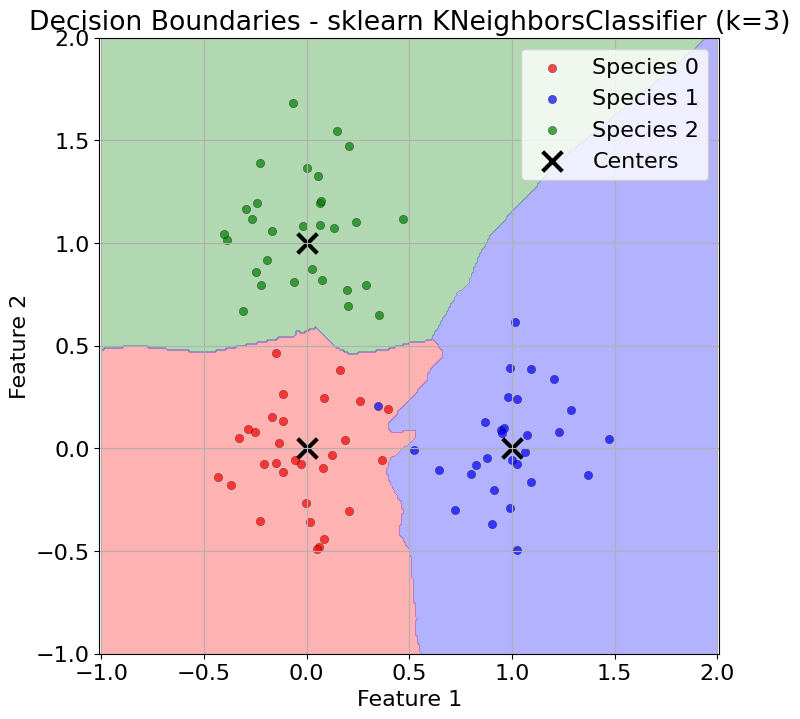

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier


# 1. Dataset generation (copied from Task 1)
initial_points = np.array([[0,0], [1, 0], [0, 1]])
train_dataset = np.array([]).reshape(0, 2)
number_generated = 30
deviation = 0.25

np.random.seed(42)
for i, center in enumerate(initial_points):
    points = np.random.normal(loc=center, scale=deviation, size=(number_generated, 2))
    train_dataset = np.vstack((train_dataset, points))

x_train = train_dataset
y_train = np.array([0]*number_generated + [1]*number_generated + [2]*number_generated)

# 2. Initialize classifier
knn = KNeighborsClassifier(n_neighbors=3)

# 3. Fit
knn.fit(x_train, y_train)

# 4. Decision boundaries on the same domain as Task 1
x_range = np.linspace(-1, 2, 300)
y_range = np.linspace(-1, 2, 300)
xx, yy = np.meshgrid(x_range, y_range)
grid_points = np.column_stack([xx.ravel(), yy.ravel()])

grid_preds_sklearn = knn.predict(grid_points).reshape(xx.shape)

# Plot
colors = ['red', 'blue', 'green']

plt.figure(figsize=(8, 8))
plt.contourf(xx, yy, grid_preds_sklearn, alpha=0.3, colors=colors, levels=[-0.5, 0.5, 1.5, 2.5])

for i in range(3):
    plt.scatter(
        train_dataset[i*number_generated:(i+1)*number_generated, 0],
        train_dataset[i*number_generated:(i+1)*number_generated, 1],
        color=colors[i], label=f"Species {i}", alpha=0.7, edgecolors='k', linewidths=0.3
    )

plt.scatter(initial_points[:, 0], initial_points[:, 1],
            color='black', marker='x', s=200, linewidths=3, label="Centers")
plt.title("Decision Boundaries - sklearn KNeighborsClassifier (k=3)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()


### Task 3 - Some more advanced techniques and a real dataset
In this task we are going to apply kNN to real data, and also learn how to split the data to test and train datasets and how to normalize it. One of the most famous educational datasets in machine learning the iris dataset, contain 150 entries of different measures of iris plants from 3 species. 

![iris](https://miro.medium.com/v2/resize:fit:4800/format:webp/1*ZK9_HrpP_lhSzTq9xVJUQw.png)
1. We loaded the data for you, first apply the imported `train_test_split` method, to split the data to 80 % train and 20 % test data.
2. Normalize the feature space by hand:
    $$
    x^\prime = (x - \overline{x})/\sigma_x
    $$
    where $\overline{x}$ is the average of a given feature and $\sigma_{x}$ is the standard deviation. The average and the standard deviation have to be calculated for the training data, and both the training and the test data have to be transformed with these values.
3. Use the built in `StandardScaler` and perform the previous calculation.
4. Train and fit a model with $k=3$.
5. Calculate and print the imported metrics, (`accuracy_score`, `classification_report`, `confusion_matrix`). What are they teaching you about your models precision? 

**Scaling is very important for data with different ranges along different dimensions, see why!**

6. Remove the scaling part of your code and see what happens if you fit your model for this data, how the metrics are change?

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the Iris dataset
iris = load_iris()
X, y = iris.data, iris.target  # Features and labels
print(iris.feature_names)

# 1. Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

# 2. Normalize by hand
# Compute mean and std on training data only
x_mean = X_train.mean(axis=0)
x_std  = X_train.std(axis=0)

X_train_manual = (X_train - x_mean) / x_std
X_test_manual  = (X_test  - x_mean) / x_std   # use TRAIN stats for test too

# 3. StandardScaler (should give identical results)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit on train, transform train
X_test_scaled  = scaler.transform(X_test)        # transform test with train stats

# Quick sanity check: are the two approaches equivalent?
print(f"\nManual vs StandardScaler max difference: "
      f"{np.max(np.abs(X_train_manual - X_train_scaled)):.2e}")

# 4. Train kNN (k=3) on scaled data
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

# 5. Metrics
print("\n--- WITH scaling ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred, target_names=iris.target_names))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

# 6. Without scaling
knn_unscaled = KNeighborsClassifier(n_neighbors=3)
knn_unscaled.fit(X_train, y_train)
y_pred_unscaled = knn_unscaled.predict(X_test)

print("\n--- WITHOUT scaling ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_unscaled):.4f}\n")
print(classification_report(y_test, y_pred_unscaled, target_names=iris.target_names))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_unscaled))

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Train size: 120, Test size: 30

Manual vs StandardScaler max difference: 0.00e+00

--- WITH scaling ---
Accuracy: 1.0000

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Confusion matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

--- WITHOUT scaling ---
Accuracy: 1.0000

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00 

### Homework
<img src="https://allisonhorst.github.io/palmerpenguins/reference/figures/lter_penguins.png" alt="drawing" width="600"/>

In this exercise you have to analyze the Palmer Penguin dataset. Your task is to train a kNN model to classify the penguin species.
1. **Data exploaration:** Load the dataset, for that you have to install `seaborn`.
    ```python
    import seaborn as sns
    penguins = sns.load_dataset("penguins")
    ```

    Print the first few rows of the data to see what features are in it. Use `sns.pairplot` to visualize your data and get more insight. (2 points)
2. **Data preparation:**  Handle the missing values properly (drop them). Encode the species into numeric values. Standardize the feature space (normalize each feature to have the same mean and standard deviation). (2 points)

3. **Model building:** Split the data into training (80%) and testing (20%) sets with `train_test_split`. Use `KNeighborsClassifier` from `scikit-learn` to build your k-NN model with $k = 3$. (2 points)

4. **Model evaluation:** Calculate the accuracy of your model (the percentage of the correct predictions). Plot the confusion matrix. And print the classification report. (2 points)

5. **Parameter tuning** Use different values of `k` from 1 to 20. Plot the accuracy as a function of `k`. To do that split the data to training (64 %), validation (16 %) and test (20 %). Train your model with the training data and perform the hyperparameter tuning on the validation data. What is the optimal `k`? What is the accuracy of the model on the test data? Use `random_state=7` (2 points)

**Bonus** Try to use all features, also the ones with categories (`island`,`sex`). Use *one-hot encoding* for these features, to convert them to numeric values, then repeat the same study. Is it improve the model? (+2 points)

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  

Shape: (344, 7)

Missing values:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


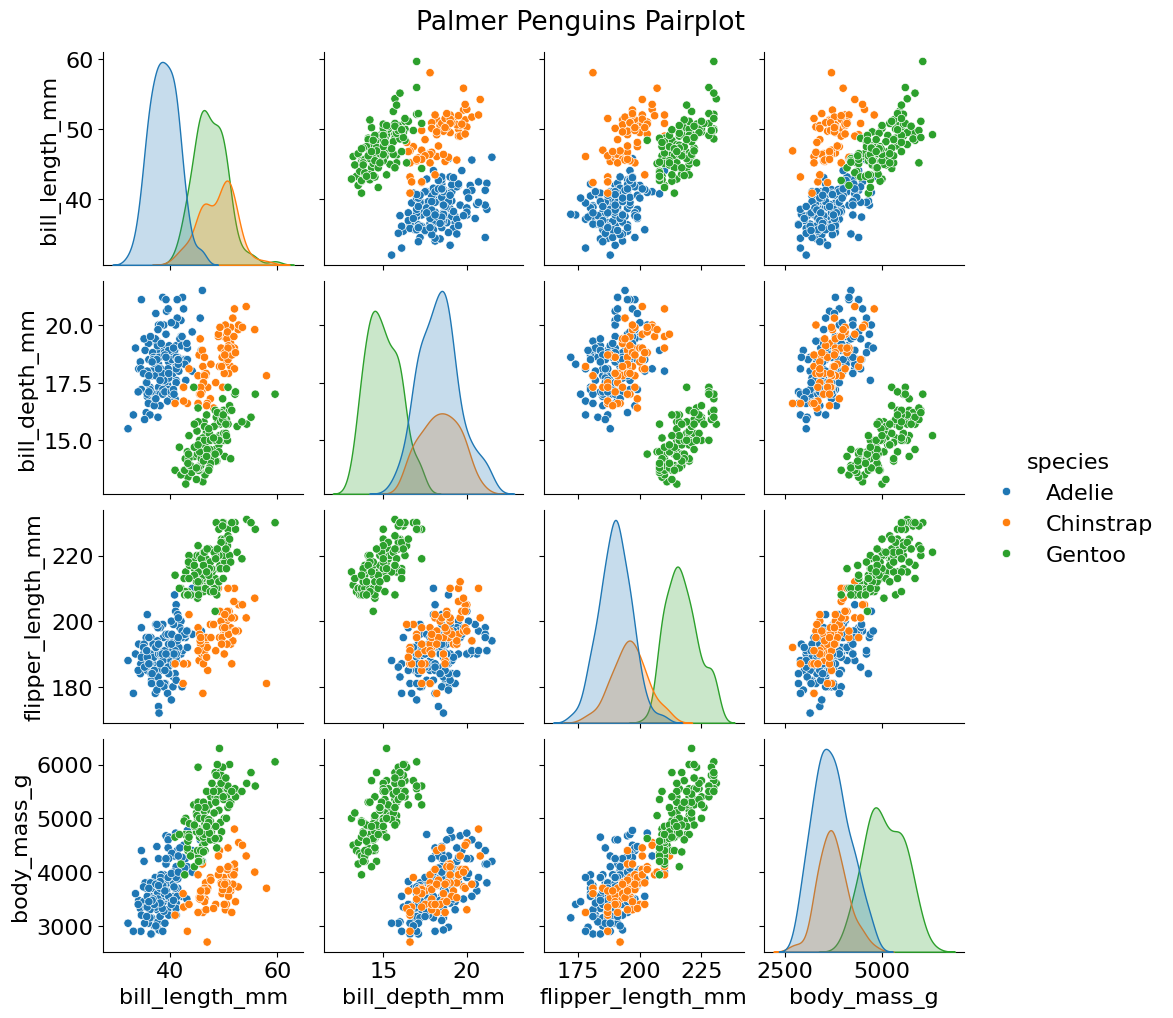


Shape after dropping NaNs: (333, 7)
Species mapping: {'Adelie': 0, 'Chinstrap': 1, 'Gentoo': 2}

--- Model Evaluation (k=3) ---
Accuracy: 1.0000

              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        31
   Chinstrap       1.00      1.00      1.00        13
      Gentoo       1.00      1.00      1.00        23

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



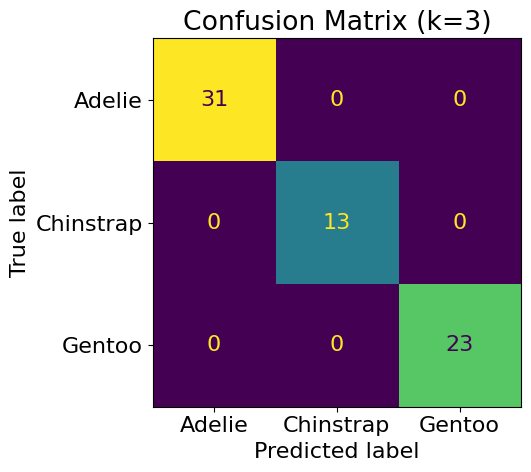


Hyperparameter tuning split sizes — train: 212, val: 54, test: 67

Best k: 3  (validation accuracy: 1.0000)


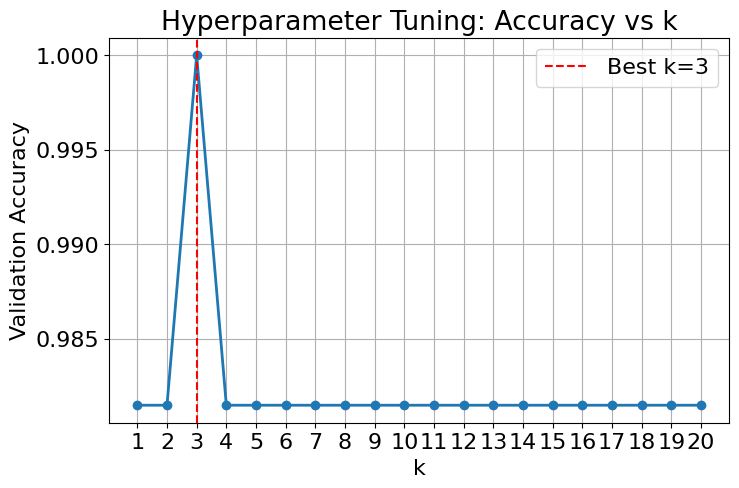

Test accuracy with best k=3: 0.9552

Bonus feature count: 9  (4 numeric + 5 one-hot)


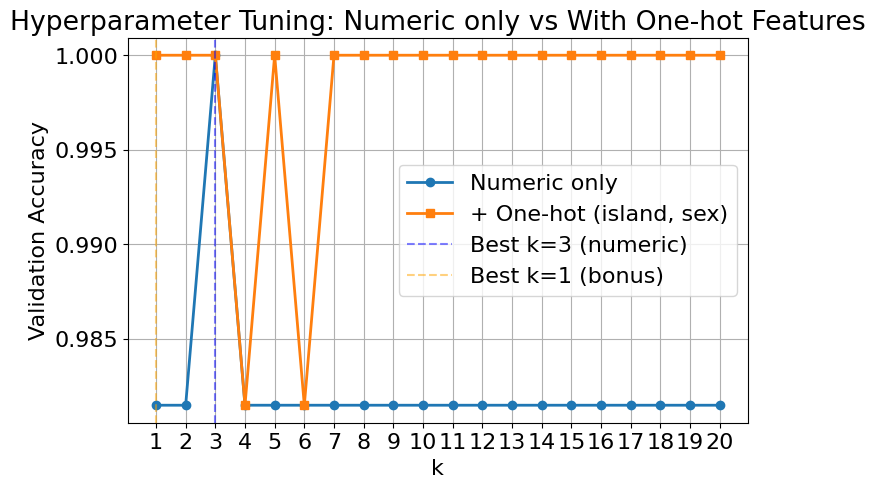


Bonus test accuracy with best k=1: 1.0000
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        28
   Chinstrap       1.00      1.00      1.00        15
      Gentoo       1.00      1.00      1.00        24

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# =============================================================================
# 1. Data Exploration
# =============================================================================
penguins = sns.load_dataset("penguins")
print(penguins.head())
print(f"\nShape: {penguins.shape}")
print(f"\nMissing values:\n{penguins.isnull().sum()}")

sns.pairplot(penguins, hue="species")
plt.suptitle("Palmer Penguins Pairplot", y=1.02)
plt.show()

# =============================================================================
# 2. Data Preparation
# =============================================================================
# Drop missing values
penguins_clean = penguins.dropna().reset_index(drop=True)
print(f"\nShape after dropping NaNs: {penguins_clean.shape}")

# Encode species to numeric labels
le = LabelEncoder()
y = le.fit_transform(penguins_clean["species"])   # Adelie=0, Chinstrap=1, Gentoo=2
print(f"Species mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Select numeric features only (for now)
numeric_features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
X = penguins_clean[numeric_features].values

# =============================================================================
# 3. Model Building  (80/20 split, k=3)
# =============================================================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

# =============================================================================
# 4. Model Evaluation
# =============================================================================
print("\n--- Model Evaluation (k=3) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=le.classes_).plot(ax=ax, colorbar=False)
plt.title("Confusion Matrix (k=3)")
plt.tight_layout()
plt.show()

# =============================================================================
# 5. Hyperparameter Tuning  (64% train / 16% val / 20% test)
# =============================================================================
# First carve out the 20% test set, then split remainder 80/20 → 64/16 overall
X_trainval, X_test_ht, y_trainval, y_test_ht = train_test_split(
    X, y, test_size=0.2, random_state=7)
X_train_ht, X_val_ht, y_train_ht, y_val_ht = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=7)

print(f"\nHyperparameter tuning split sizes — "
      f"train: {len(X_train_ht)}, val: {len(X_val_ht)}, test: {len(X_test_ht)}")

# Scale using training stats only
scaler_ht = StandardScaler()
X_train_ht_s = scaler_ht.fit_transform(X_train_ht)
X_val_ht_s   = scaler_ht.transform(X_val_ht)
X_test_ht_s  = scaler_ht.transform(X_test_ht)

k_values   = np.arange(1, 21)
val_accuracies  = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_ht_s, y_train_ht)
    val_accuracies.append(accuracy_score(y_val_ht, model.predict(X_val_ht_s)))

best_k = k_values[np.argmax(val_accuracies)]
print(f"\nBest k: {best_k}  (validation accuracy: {max(val_accuracies):.4f})")

plt.figure(figsize=(8, 5))
plt.plot(k_values, val_accuracies, marker='o', linewidth=2)
plt.axvline(best_k, color='red', linestyle='--', label=f"Best k={best_k}")
plt.xticks(k_values)
plt.xlabel("k")
plt.ylabel("Validation Accuracy")
plt.title("Hyperparameter Tuning: Accuracy vs k")
plt.legend()
plt.grid(True)
plt.show()

# Final evaluation on held-out test set using best_k
best_model = KNeighborsClassifier(n_neighbors=best_k)
best_model.fit(X_train_ht_s, y_train_ht)
y_pred_best = best_model.predict(X_test_ht_s)
print(f"Test accuracy with best k={best_k}: {accuracy_score(y_test_ht, y_pred_best):.4f}")

# =============================================================================
# BONUS: One-hot encode categorical features (island, sex)
# =============================================================================
import pandas as pd

penguins_bonus = penguins_clean.copy()

# One-hot encode island and sex, drop_first=False to keep all categories explicit
ohe_cols = pd.get_dummies(penguins_bonus[["island", "sex"]], drop_first=False).astype(float)
X_bonus = np.hstack([penguins_clean[numeric_features].values, ohe_cols.values])

print(f"\nBonus feature count: {X_bonus.shape[1]}  "
      f"({len(numeric_features)} numeric + {ohe_cols.shape[1]} one-hot)")

# Same 64/16/20 split with random_state=7
X_trainval_b, X_test_b, y_trainval_b, y_test_b = train_test_split(
    X_bonus, y, test_size=0.2, random_state=7)
X_train_b, X_val_b, y_train_b, y_val_b = train_test_split(
    X_trainval_b, y_trainval_b, test_size=0.2, random_state=7)

scaler_b = StandardScaler()
X_train_b_s = scaler_b.fit_transform(X_train_b)
X_val_b_s   = scaler_b.transform(X_val_b)
X_test_b_s  = scaler_b.transform(X_test_b)

val_acc_bonus = []
for k in k_values:
    m = KNeighborsClassifier(n_neighbors=k)
    m.fit(X_train_b_s, y_train_b)
    val_acc_bonus.append(accuracy_score(y_val_b, m.predict(X_val_b_s)))

best_k_b = k_values[np.argmax(val_acc_bonus)]

plt.figure(figsize=(8, 5))
plt.plot(k_values, val_accuracies, marker='o', linewidth=2, label="Numeric only")
plt.plot(k_values, val_acc_bonus,  marker='s', linewidth=2, label="+ One-hot (island, sex)")
plt.axvline(best_k,   color='blue', linestyle='--', alpha=0.5, label=f"Best k={best_k} (numeric)")
plt.axvline(best_k_b, color='orange', linestyle='--', alpha=0.5, label=f"Best k={best_k_b} (bonus)")
plt.xticks(k_values)
plt.xlabel("k")
plt.ylabel("Validation Accuracy")
plt.title("Hyperparameter Tuning: Numeric only vs With One-hot Features")
plt.legend()
plt.grid(True)
plt.show()

# Final test accuracy for bonus model
best_model_b = KNeighborsClassifier(n_neighbors=best_k_b)
best_model_b.fit(X_train_b_s, y_train_b)
y_pred_b = best_model_b.predict(X_test_b_s)
print(f"\nBonus test accuracy with best k={best_k_b}: {accuracy_score(y_test_b, y_pred_b):.4f}")
print(classification_report(y_test_b, y_pred_b, target_names=le.classes_))